In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#!/bin/bash
!mkdir -p ~/Downloads
!curl -L -o ~/Downloads/breast-ultrasound-images-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/sabahesaraki/breast-ultrasound-images-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  194M  100  194M    0     0  15.2M      0  0:00:12  0:00:12 --:--:-- 16.6M


In [ ]:
!unzip -q ~/Downloads/breast-ultrasound-images-dataset.zip -d .

replace ./Dataset_BUSI_with_GT/benign/benign (1).png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Input, Conv2D, SeparableConv2D,
    BatchNormalization, MaxPooling2D, GlobalAveragePooling2D,
    Dropout, Dense, Activation)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
import tensorflow.keras.callbacks as C

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Data — Exclude Mask Images

Total images: 780
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


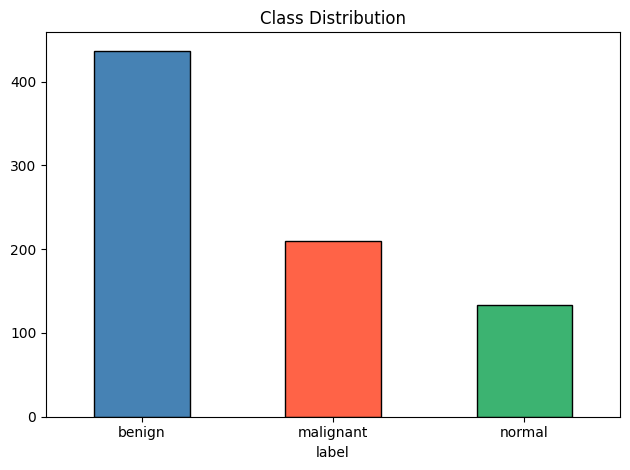

In [ ]:
DATA_DIR = "./Dataset_BUSI_with_GT"

filepaths, labels = [], []

for label in os.listdir(DATA_DIR):
    folder = os.path.join(DATA_DIR, label)
    if not os.path.isdir(folder):
        continue
    for file in sorted(os.listdir(folder)):
        if "_mask" in file:
            continue
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            filepaths.append(os.path.join(folder, file))
            labels.append(label)

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print(f"Total images: {len(df)}")
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar",
    color=["steelblue","tomato","mediumseagreen"], edgecolor="black")
plt.title("Class Distribution"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 3. Stratified 70 / 15 / 15 Split

In [ ]:
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df["label"], random_state=42)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.176, stratify=train_val_df["label"], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("\nTrain class counts:"); print(train_df["label"].value_counts())
print("\nTest class counts:");  print(test_df["label"].value_counts())


Train: 546  Val: 117  Test: 117

Train class counts:
label
benign       306
malignant    147
normal        93
Name: count, dtype: int64

Test class counts:
label
benign       66
malignant    31
normal       20
Name: count, dtype: int64


## 4. Config

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 30
STEPS_PER_EPOCH = len(train_df) // BATCH_SIZE
print(f"Steps per epoch (fixed for all models): {STEPS_PER_EPOCH}")


Steps per epoch (fixed for all models): 17


In [ ]:
def make_datagen(augment=False):
    """Safe rescale-only normalisation. Augmentation added on demand."""
    kwargs = dict(rescale=1./255)
    if augment:
        kwargs.update(
            horizontal_flip=True,
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.15,
            brightness_range=[0.8, 1.2],
            fill_mode="nearest"
        )
    return ImageDataGenerator(**kwargs)


def make_gen(datagen, dataframe, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42
    )

std_datagen = make_datagen(augment=False)
aug_datagen = make_datagen(augment=True)

train_gen     = make_gen(std_datagen, train_df, shuffle=True)
val_gen       = make_gen(std_datagen, val_df,   shuffle=False)
test_gen      = make_gen(std_datagen, test_df,  shuffle=False)
train_aug_gen = make_gen(aug_datagen, train_df, shuffle=True)

CLASS_NAMES = list(train_gen.class_indices.keys())
print("Class indices:", train_gen.class_indices)

# Calculate class weights for imbalance
_label_to_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.sort(train_df["label"].unique()),
    y=train_df["label"]
)
_label_to_weight = {cls: w for cls, w in zip(np.sort(train_df["label"].unique()), _label_to_weight)}
print("Raw class weights:", _label_to_weight)

CLASS_WEIGHT = {
    idx: _label_to_weight[label]
    for label, idx in train_gen.class_indices.items()
}
print("\nClass weight dict (index → weight):")
for idx, w in CLASS_WEIGHT.items():
    print(f"  Class {idx} ({CLASS_NAMES[idx]}): {w:.4f}")

Found 546 validated image filenames belonging to 3 classes.
Found 117 validated image filenames belonging to 3 classes.
Found 117 validated image filenames belonging to 3 classes.
Found 546 validated image filenames belonging to 3 classes.
Class indices: {'benign': 0, 'malignant': 1, 'normal': 2}
Raw class weights: {'benign': np.float64(0.5947712418300654), 'malignant': np.float64(1.2380952380952381), 'normal': np.float64(1.956989247311828)}

Class weight dict (index → weight):
  Class 0 (benign): 0.5948
  Class 1 (malignant): 1.2381
  Class 2 (normal): 1.9570


## 7. Oversampled Generator

In [ ]:
max_count = train_df["label"].value_counts().max()
parts = []
for lbl, grp in train_df.groupby("label"):
    parts.append(grp.sample(n=max_count, replace=True, random_state=42))

over_df = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
print("Oversampled counts:"); print(over_df["label"].value_counts())

train_over_gen = make_gen(std_datagen, over_df, shuffle=True)


Oversampled counts:
label
normal       306
benign       306
malignant    306
Name: count, dtype: int64
Found 918 validated image filenames belonging to 3 classes.


In [ ]:
REG = l2(1e-4)

def bn():
    return BatchNormalization(momentum=0.85, epsilon=1e-3)

def conv_block(x, filters):
    for _ in range(2):
        x = Conv2D(filters, 3, padding="same", use_bias=False,
                   kernel_regularizer=REG)(x)
        x = bn()(x)
        x = Activation("relu")(x)
    return x

def ds_block(x, filters):
    for _ in range(2):
        x = SeparableConv2D(filters, 3, padding="same", use_bias=False,
                            depthwise_regularizer=REG,
                            pointwise_regularizer=REG)(x)
        x = bn()(x)
        x = Activation("relu")(x)
    return x

def head(x, num_classes=3):
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation="relu", kernel_regularizer=REG)(x)
    x = Dropout(0.3)(x)
    return Dense(num_classes, activation="softmax")(x)


def build_baseline_cnn():
    inp = Input(shape=(224, 224, 3))
    x = conv_block(inp, 32);  x = MaxPooling2D()(x)
    x = conv_block(x,   64);  x = MaxPooling2D()(x)
    x = conv_block(x,  128);  x = MaxPooling2D()(x)
    x = Conv2D(256, 3, padding="same", use_bias=False, kernel_regularizer=REG)(x)
    x = bn()(x); x = Activation("relu")(x)
    return Model(inp, head(x), name="Baseline_CNN")


def build_ds_cnn():
    inp = Input(shape=(224, 224, 3))
    x = ds_block(inp, 32);  x = MaxPooling2D()(x)
    x = ds_block(x,   64);  x = MaxPooling2D()(x)
    x = ds_block(x,  128);  x = MaxPooling2D()(x)
    x = SeparableConv2D(256, 3, padding="same", use_bias=False,
                        depthwise_regularizer=REG,
                        pointwise_regularizer=REG)(x)
    x = bn()(x); x = Activation("relu")(x)
    return Model(inp, head(x), name="DS_CNN")

print(f"Baseline CNN params : {build_baseline_cnn().count_params():,}")
print(f"DS-CNN params       : {build_ds_cnn().count_params():,}")


Baseline CNN params : 617,571
DS-CNN params       : 104,766


## 9. Focal Loss

In [ ]:
def focal_loss(gamma=2.0):
    """Focal loss: down-weights easy samples, focuses on hard ones."""
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce     = -y_true * tf.math.log(y_pred)
        weight = tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    loss_fn.__name__ = "focal_loss"
    return loss_fn

In [ ]:
def train_model(model, train_data, loss_fn="categorical_crossentropy"):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    val_gen.reset()


    return model.fit(
        train_data,
        validation_data=val_gen,
        epochs=EPOCHS,
        steps_per_epoch=STEPS_PER_EPOCH,
        class_weight=CLASS_WEIGHT,
        verbose=1
    )


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history["loss"],         label="Train")
    axes[0].plot(history.history["val_loss"],     label="Val")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend()
    axes[1].plot(history.history["accuracy"],     label="Train")
    axes[1].plot(history.history["val_accuracy"], label="Val")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend()
    plt.tight_layout() #; plt.show()

## 11. Evaluation Function

In [ ]:
all_results = []

def evaluate_model(model, name):
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    y_true = test_gen.classes

    min_len = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:min_len], y_pred[:min_len]

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout() #; plt.show()

    all_results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "F1-Score":  round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
    })
    return y_true, y_pred

---
## Model — Baseline CNN

  BASELINE CNN
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.3930 - loss: 1.2103 - val_accuracy: 0.2735 - val_loss: 1.4289
Epoch 2/30
 1/17 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.4062 - loss: 1.2456

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.4062 - loss: 1.2456 - val_accuracy: 0.2735 - val_loss: 1.4137
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 454ms/step - accuracy: 0.4743 - loss: 1.0980 - val_accuracy: 0.4103 - val_loss: 1.1361
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5000 - loss: 0.8376 - val_accuracy: 0.4274 - val_loss: 1.1124
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 399ms/step - accuracy: 0.5078 - loss: 0.9926 - val_accuracy: 0.6068 - val_loss: 0.9717
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5625 - loss: 0.9046 - val_accuracy: 0.5726 - val_loss: 0.9541
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 458ms/step - accuracy: 0.5681 - loss: 0.9873 - val_accuracy: 0.5641 - val_loss: 1.1305
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.4688 - loss: 0.8466 - val_accuracy: 0.5470 - val_loss: 1.0700
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 501ms/step - accuracy: 0.5253 - loss: 0.9771 - val_accuracy: 0.3504 - val_los

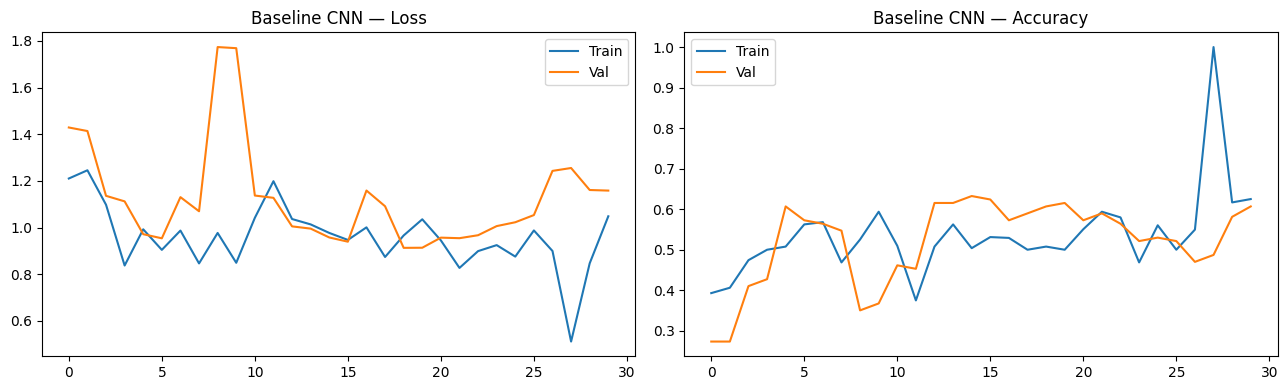

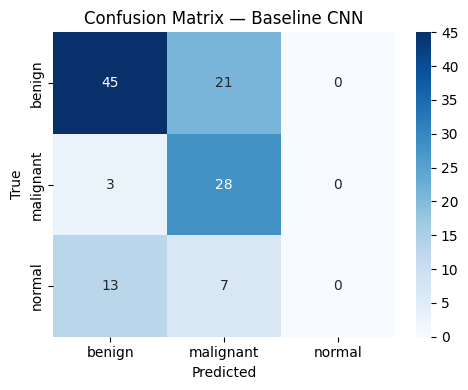

In [ ]:
print("=" * 50)
print("  BASELINE CNN")
print("=" * 50)
baseline = build_baseline_cnn()
h_baseline = train_model(baseline, train_gen)
plot_history(h_baseline, "Baseline CNN")
y_true_baseline, y_pred_baseline = evaluate_model(baseline, "Baseline CNN")

---
## Model — DS-CNN

  DS-CNN
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3521 - loss: 1.2608 - val_accuracy: 0.2735 - val_loss: 1.2736
Epoch 2/30
 1/17 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.5938 - loss: 1.2118

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5938 - loss: 1.2118 - val_accuracy: 0.2735 - val_loss: 1.2876
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 351ms/step - accuracy: 0.4591 - loss: 1.1696 - val_accuracy: 0.2735 - val_loss: 1.5963
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.7188 - loss: 1.0023 - val_accuracy: 0.2735 - val_loss: 1.5856
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 395ms/step - accuracy: 0.4844 - loss: 1.1311 - val_accuracy: 0.4359 - val_loss: 1.1580
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.4375 - loss: 0.9469 - val_accuracy: 0.4530 - val_loss: 1.1386
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 436ms/step - accuracy: 0.4494 - loss: 1.1345 - val_accuracy: 0.4786 - val_loss: 1.1064
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5000 - loss: 0.9623 - val_accuracy: 0.4701 - val_loss: 1.1048
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step - accuracy: 0.4805 - loss: 1.0906 - val_accuracy: 0.5043 - val_loss

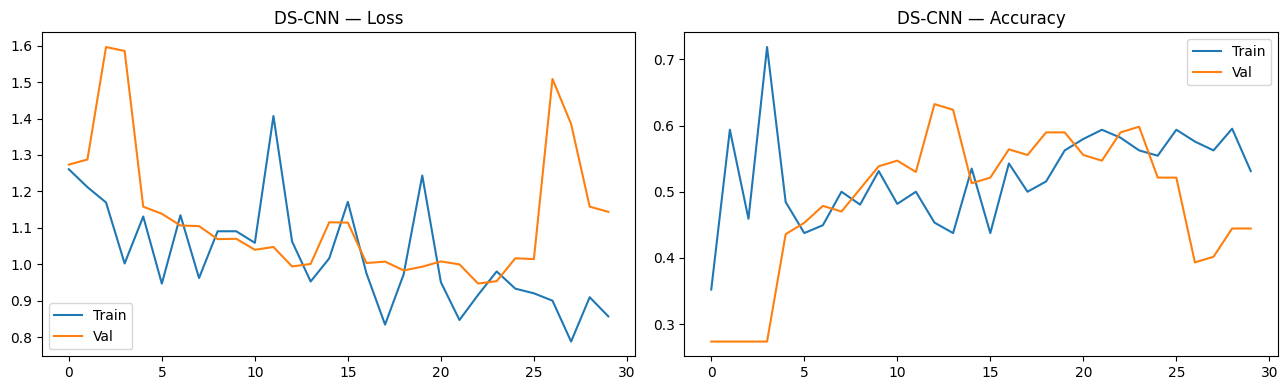

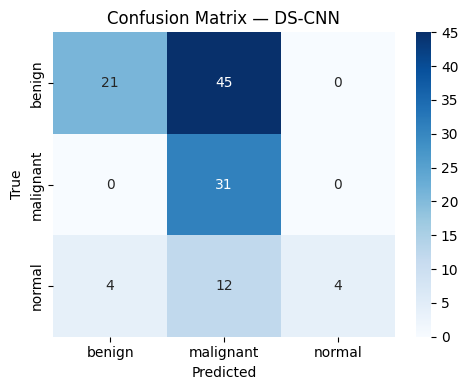

In [ ]:
print("=" * 50)
print("  DS-CNN")
print("=" * 50)
ds_cnn = build_ds_cnn()
h_ds_cnn = train_model(ds_cnn, train_gen)
plot_history(h_ds_cnn, "DS-CNN")
y_true_ds_cnn, y_pred_ds_cnn = evaluate_model(ds_cnn, "DS-CNN")

---
## Model — DS-CNN + Focal Loss

  DS-CNN + FOCAL LOSS
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.4222 - loss: 0.6317 - val_accuracy: 0.2735 - val_loss: 0.5735
Epoch 2/30
 1/17 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.5625 - loss: 0.4876

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5625 - loss: 0.4876 - val_accuracy: 0.2735 - val_loss: 0.5748
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 387ms/step - accuracy: 0.5214 - loss: 0.5229 - val_accuracy: 0.2735 - val_loss: 0.7072
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4375 - loss: 0.6337 - val_accuracy: 0.2735 - val_loss: 0.6976
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - accuracy: 0.5311 - loss: 0.5003 - val_accuracy: 0.5641 - val_loss: 0.4781
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4062 - loss: 0.5563 - val_accuracy: 0.5641 - val_loss: 0.4774
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step - accuracy: 0.4853 - loss: 0.5078 - val_accuracy: 0.5726 - val_loss: 0.4757
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 1.0000 - loss: 0.1570 - val_accuracy: 0.5556 - val_loss: 0.4697
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step - accuracy: 0.5564 - loss: 0.4853 - val_accuracy: 0.5726 - val_loss


  DS-CNN + Focal Loss
              precision    recall  f1-score   support

      benign       0.61      0.95      0.75        66
   malignant       0.71      0.32      0.44        31
      normal       0.00      0.00      0.00        20

    accuracy                           0.62       117
   macro avg       0.44      0.43      0.40       117
weighted avg       0.53      0.62      0.54       117



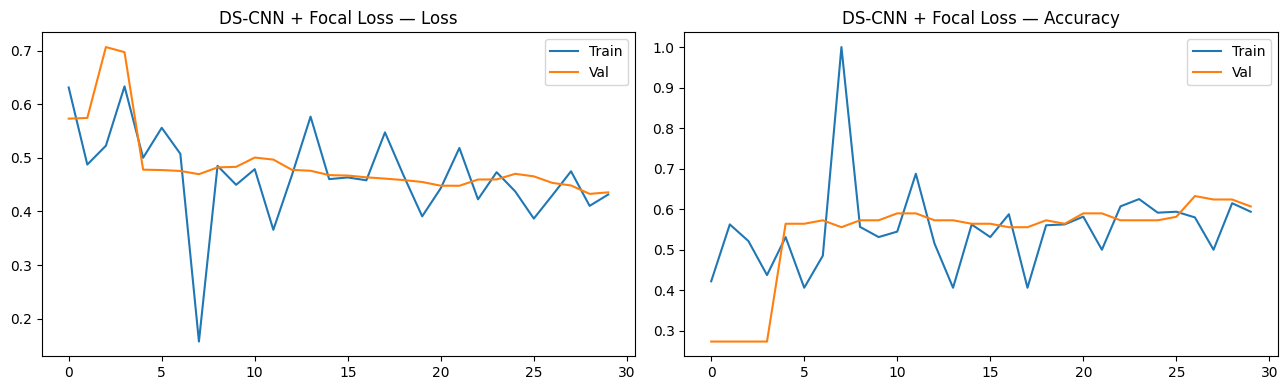

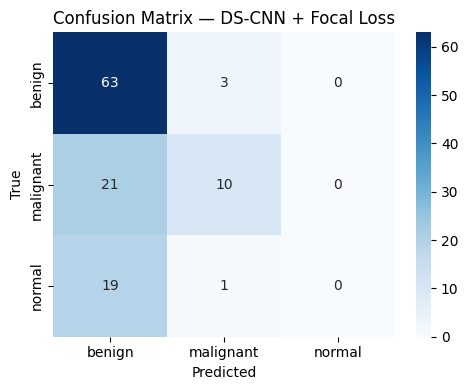

In [ ]:
print("=" * 50)
print("  DS-CNN + FOCAL LOSS")
print("=" * 50)
ds_focal = build_ds_cnn()
h_ds_focal = train_model(ds_focal, train_gen, loss_fn=focal_loss(gamma=2.0))
plot_history(h_ds_focal, "DS-CNN + Focal Loss")
y_true_ds_focal, y_pred_ds_focal = evaluate_model(ds_focal, "DS-CNN + Focal Loss")

---
## Model — DS-CNN + Augmentation

  DS-CNN + AUGMENTATION
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.3911 - loss: 1.2238 - val_accuracy: 0.2735 - val_loss: 1.1858
Epoch 2/30
 1/17 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.4375 - loss: 1.2377

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4375 - loss: 1.2377 - val_accuracy: 0.2735 - val_loss: 1.1924
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 729ms/step - accuracy: 0.3872 - loss: 1.2150 - val_accuracy: 0.2735 - val_loss: 1.2867
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4062 - loss: 1.2514 - val_accuracy: 0.2735 - val_loss: 1.2765
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 736ms/step - accuracy: 0.3677 - loss: 1.1973 - val_accuracy: 0.2906 - val_loss: 1.1821
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.3750 - loss: 1.1756 - val_accuracy: 0.3077 - val_loss: 1.1689
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 740ms/step - accuracy: 0.3971 - loss: 1.1692 - val_accuracy: 0.5556 - val_loss: 1.0446
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5000 - loss: 0.9399 - val_accuracy: 0.5556 - val_loss: 1.0357
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 722ms/step - accuracy: 0.4358 - loss: 1.1449 - val_accuracy: 0.5812 - val_

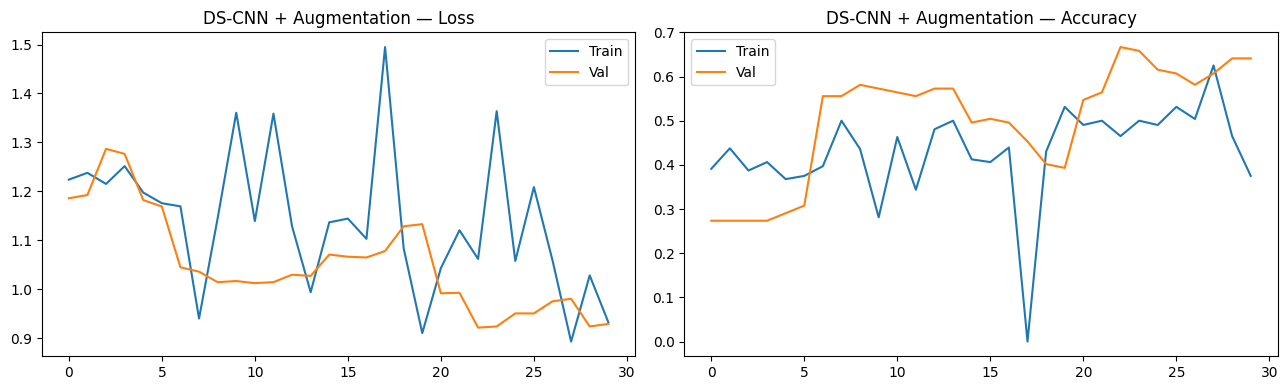

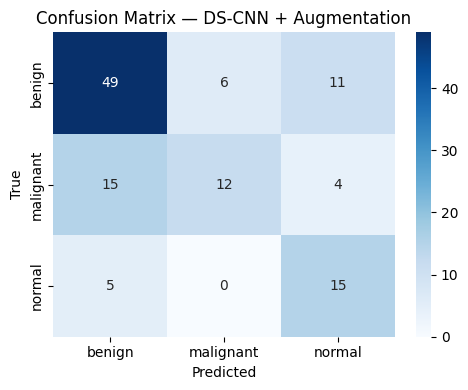

In [ ]:
print("=" * 50)
print("  DS-CNN + AUGMENTATION")
print("=" * 50)
ds_aug = build_ds_cnn()
h_ds_aug = train_model(ds_aug, train_aug_gen)
plot_history(h_ds_aug, "DS-CNN + Augmentation")
y_true_ds_aug, y_pred_ds_aug = evaluate_model(ds_aug, "DS-CNN + Augmentation")

---
## Model — DS-CNN + Oversampling

  DS-CNN + OVERSAMPLING
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 827ms/step - accuracy: 0.3860 - loss: 1.4999 - val_accuracy: 0.1709 - val_loss: 1.3364
Epoch 2/30
12/17 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3797 - loss: 1.3413

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


17/17 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4091 - loss: 1.3188 - val_accuracy: 0.2735 - val_loss: 1.8014
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 406ms/step - accuracy: 0.4625 - loss: 1.2401 - val_accuracy: 0.3077 - val_loss: 1.4728
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 253ms/step - accuracy: 0.4740 - loss: 1.1928 - val_accuracy: 0.2308 - val_loss: 1.6009
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 425ms/step - accuracy: 0.4835 - loss: 1.2292 - val_accuracy: 0.2735 - val_loss: 1.4683
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.5134 - loss: 1.1826 - val_accuracy: 0.3761 - val_loss: 1.2776
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 462ms/step - accuracy: 0.5221 - loss: 1.1280 - val_accuracy: 0.3675 - val_loss: 1.3447
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step - accuracy: 0.5027 - loss: 1.1586 - val_accuracy: 0.3675 - val_loss: 1.2959
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 446ms/step - accuracy: 0.5150 - loss: 1.0931 - val_accuracy: 0.3761 - val_lo

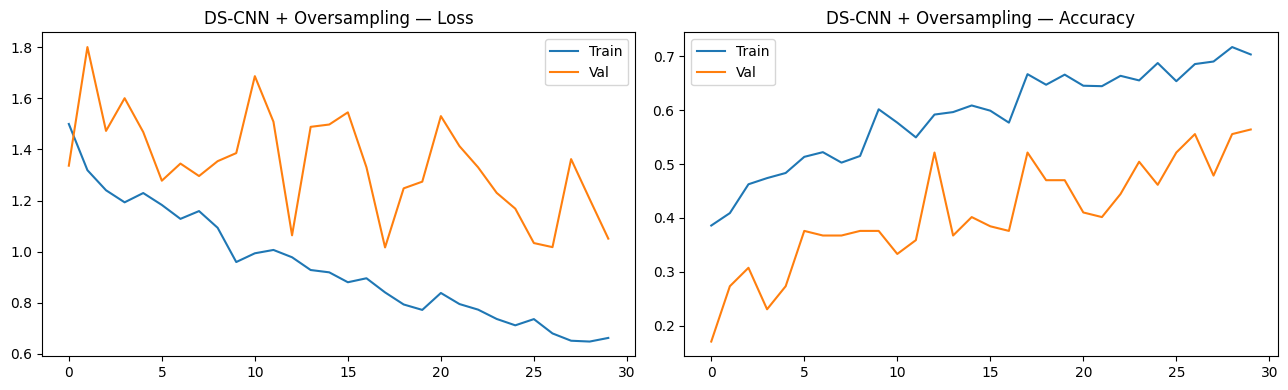

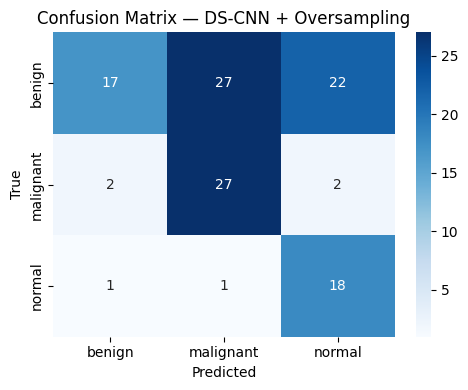

In [ ]:
print("=" * 50)
print("  DS-CNN + OVERSAMPLING")
print("=" * 50)
ds_over = build_ds_cnn()
h_ds_over = train_model(ds_over, train_over_gen)
plot_history(h_ds_over, "DS-CNN + Oversampling")
y_true_ds_over, y_pred_ds_over = evaluate_model(ds_over, "DS-CNN + Oversampling")

---
## Final Comparison Table

                Model  Accuracy  Precision  Recall  F1-Score
DS-CNN + Augmentation    0.6496     0.6627  0.6496    0.6418
         Baseline CNN    0.6239     0.5486  0.6239    0.5703
  DS-CNN + Focal Loss    0.6239     0.5343  0.6239    0.5383
DS-CNN + Oversampling    0.5299     0.6828  0.5299    0.4886
               DS-CNN    0.4786     0.7381  0.4786    0.4554


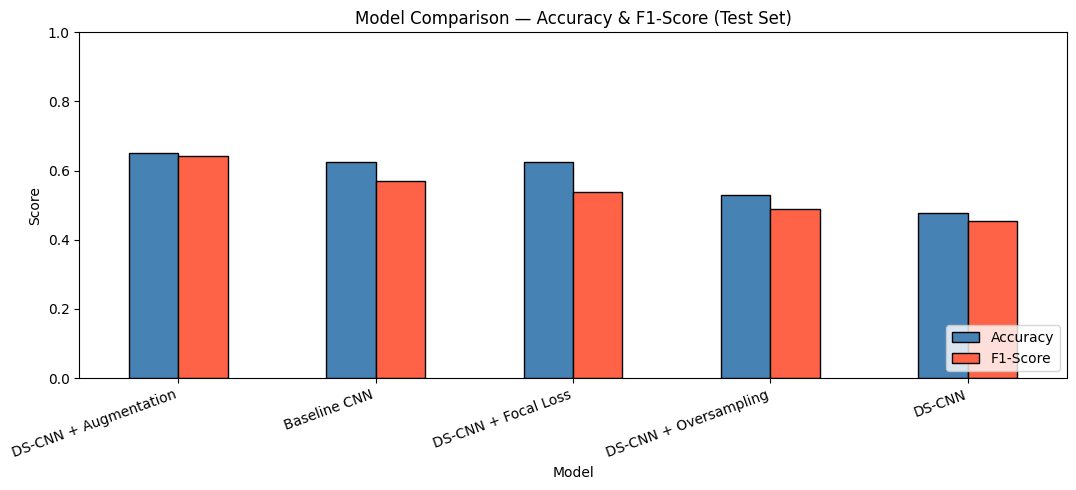

In [ ]:
results_df = (pd.DataFrame(all_results)
               .sort_values("F1-Score", ascending=False)
               .reset_index(drop=True))

print(results_df.to_string(index=False))

results_df.set_index("Model")[["Accuracy","F1-Score"]].plot(
    kind="bar", figsize=(11, 5),
    color=["steelblue","tomato"], edgecolor="black"
)
plt.title("Model Comparison — Accuracy & F1-Score (Test Set)")
plt.ylabel("Score"); plt.ylim(0, 1.0)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()